#**Data Fetching & Preprocessing**


*   Used yfinance to download historical S&P 500 index data (^GSPC).

*   Cached data locally to avoid repeated downloads.

*   Removed irrelevant columns like Dividends and Stock Splits.

*   Created a binary target: whether tomorrow’s close is greater than today’s.

*   Filtered the dataset from 1990 onwards to ensure consistency.















In [ ]:
import yfinance as yf
import pandas as pd
import os

In [ ]:
if os.path.exists("sp500.csv"):
    sp500 = pd.read_csv("sp500.csv", index_col=0)
else:
    sp500 = yf.Ticker("^GSPC")
    sp500 = sp500.history(period="max")
    sp500.to_csv("sp500.csv")

In [ ]:
sp500.index = pd.to_datetime(sp500.index)

In [ ]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2025-04-04 00:00:00-04:00,5292.140137,5292.140137,5069.899902,5074.080078,8853500000,0.0,0.0
2025-04-07 00:00:00-04:00,4953.790039,5246.569824,4835.040039,5062.250000,8691980000,0.0,0.0
2025-04-08 00:00:00-04:00,5193.569824,5267.470215,4910.419922,4982.770020,7408140000,0.0,0.0


<Axes: xlabel='Date'>

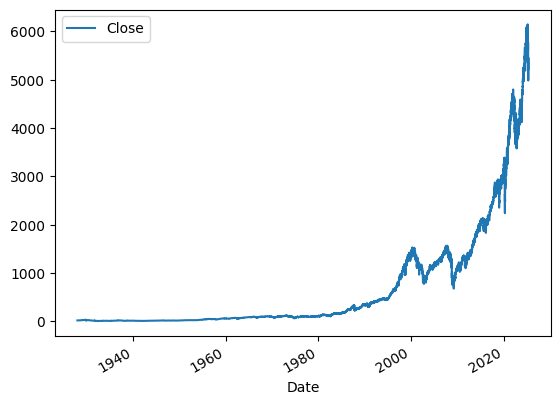

In [ ]:
sp500.plot.line(y="Close", use_index=True)

In [ ]:
del sp500["Dividends"]
del sp500["Stock Splits"]

In [ ]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [ ]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [ ]:
sp500 = sp500.loc["1990-01-01":].copy()

#**Baseline Models**

.
*   Used predictors: Open, High, Low, Close, Volume


*   Evaluated models using Precision Score.


*   Visualized predictions vs. actual movements





**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [ ]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision_score(test["Target"], preds)

0.45

<Axes: xlabel='Date'>

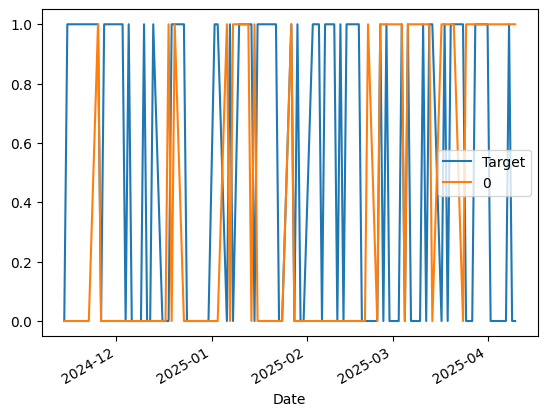

In [ ]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()
model1.fit(train[predictors], train["Target"])

LogisticRegression()

In [ ]:
preds1 = model1.predict(test[predictors])
preds1 = pd.Series(preds, index=test.index)
precision_score(test["Target"], preds1)

0.45

<Axes: xlabel='Date'>

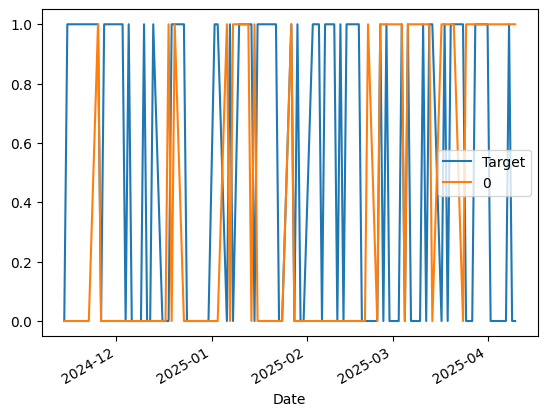

In [ ]:
combinedLR = pd.concat([test["Target"], preds1], axis=1)
combinedLR.plot()

**Aritificial Neural Network**



*   Architecture:

  *   4 hidden layers with LeakyReLU, Dropout, and BatchNormalization

  *   Final layer with Sigmoid activation for binary output

*   Used binary_crossentropy loss and Adam optimizer.

*   Trained for 50–100 epochs with adjustable learning rate.





In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

In [ ]:
ann_model = Sequential([
    Dense(128, input_dim=len(predictors)),
    BatchNormalization(),
    Dropout(0.3),
    LeakyReLU(negative_slope=0.1),

    Dense(64),
    BatchNormalization(),
    Dropout(0.2),
    LeakyReLU(negative_slope=0.1),

    Dense(32),
    BatchNormalization(),
    LeakyReLU(negative_slope=0.1),

    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.0001)


ann_model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=["Precision"]
)

history = ann_model.fit(
    train[predictors],
    train["Target"],
    epochs=100,
    verbose=1
)

Epoch 1/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - Precision: 0.5492 - loss: 0.7606
Epoch 2/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.5184 - loss: 0.7378
Epoch 3/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.5341 - loss: 0.7172
Epoch 4/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.5341 - loss: 0.7103
Epoch 5/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.5239 - loss: 0.7099
Epoch 6/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - Precision: 0.5317 - loss: 0.7064
Epoch 7/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Precision: 0.5373 - loss: 0.7013
Epoch 8/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.5302 - loss: 0.6961
Epoch 9/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.5327 - loss: 0.6986
Epoch 10/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.5464 - loss: 0.6961
Epoch 11/100
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.5424 - loss: 0.6967
Epoch 12/100
275/275 ━━━━━━━━━

In [ ]:
test_probabilities = ann_model.predict(test[predictors])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [ ]:
test_predictions = (test_probabilities > 0.5).astype(int)

In [ ]:
test_precision = ann_model.evaluate(test[predictors], test["Target"], verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - Precision: 0.5334 - loss: 0.6895 


#**Backtesting**



*   Implemented a sliding window backtesting framework:

  *   Train on rolling time windows

  *   Evaluate predictions in unseen data chunks

*   Applied backtesting on all three models: **Random Forest, Logistic Regression, ANN**

*   Evaluated precision scores and prediction distribution.





In [ ]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [ ]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

**Random Forest Backtesting**

In [ ]:
predictions = backtest(sp500, model, predictors)

In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
0,3736
1,2649


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5285013212533032

In [ ]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.53563
0,0.46437


**Logistic Regression BackTesting**

In [ ]:
predictionsLR = backtest(sp500, model1, predictors)

In [ ]:
predictionsLR["Predictions"].value_counts()

,count
Predictions,
1,5863
0,522


In [ ]:
predictionsLR["Target"].value_counts() / predictionsLR.shape[0]

,count
Target,
1,0.53563
0,0.46437


In [ ]:
precision_score(predictionsLR["Target"], predictionsLR["Predictions"])

0.5370970492921713

**ANN Backtesting**

In [ ]:
def backtest_ann(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()

        X_train = train[predictors].values.astype('float32')
        y_train = train["Target"].values.astype('float32')
        X_test = test[predictors].values.astype('float32')

        if not model.built:
            model.build(input_shape=X_train.shape)

        model.fit(X_train, y_train, epochs=10, verbose=0)

        preds = model.predict(X_test, verbose=0).flatten()
        preds = (preds > 0.5).astype(int)


        predictions = pd.concat([
            test["Target"].rename("Target"),
            pd.Series(preds, index=test.index, name="Predictions")
        ], axis=1)

        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [ ]:
ann_predictions = backtest_ann(sp500, ann_model, predictors)

In [ ]:
ann_predictions["Predictions"].value_counts()

,count
Predictions,
1,4900
0,485


In [ ]:
ann_predictions["Target"].value_counts() / ann_predictions.shape[0]

,count
Target,
1,0.545032
0,0.454968


In [ ]:
precision_score(ann_predictions["Target"], ann_predictions["Predictions"])

0.5455102040816326

##**Including Other Predictors**



*   Added technical indicators:

  *   Rolling average ratios (2, 5, 60, 250, 1000-day windows)

  *   Target trends over time

*   Integrated into model as new predictors for improved learning.




In [ ]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

    new_predictors+= [ratio_column, trend_column]

In [ ]:
sp500 = sp500.dropna(subset=sp500.columns[sp500.columns != "Tomorrow"])

In [ ]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-04 00:00:00-04:00,5292.140137,5292.140137,5069.899902,5074.080078,8853500000,5062.250000,0,0.969205,0.0,0.926384,3.0,0.865470,32.0,0.897863,141.0,1.090877,526.0
2025-04-07 00:00:00-04:00,4953.790039,5246.569824,4835.040039,5062.250000,8691980000,4982.770020,0,0.998833,0.0,0.943151,2.0,0.865558,31.0,0.895859,141.0,1.088114,526.0
2025-04-08 00:00:00-04:00,5193.569824,5267.470215,4910.419922,4982.770020,7408140000,5456.899902,1,0.992088,0.0,0.951397,1.0,0.854023,31.0,0.881935,140.0,1.070843,525.0


In [ ]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >=.6] = 1
    preds[preds <.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

**Random Forest Regressor**

In [ ]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [ ]:
predictions = backtest(sp500, model, new_predictors)

In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,4516
1.0,869


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.570771001150748

In [ ]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.545032
0,0.454968


In [ ]:
predictions

,Target,Predictions
Date,,
2003-11-14 00:00:00-05:00,0,0.0
2003-11-17 00:00:00-05:00,0,1.0
2003-11-18 00:00:00-05:00,1,1.0
2003-11-19 00:00:00-05:00,0,0.0
2003-11-20 00:00:00-05:00,1,1.0
...,...,...
2025-04-04 00:00:00-04:00,0,1.0
2025-04-07 00:00:00-04:00,0,0.0
2025-04-08 00:00:00-04:00,1,1.0


**Logistic Regression**

In [ ]:
modelLR = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    penalty='l2',
    C=1.0,
    random_state=1
)

In [ ]:
predictionsLR=backtest(sp500, modelLR, new_predictors)

In [ ]:
predictionsLR["Predictions"].value_counts()

,count
Predictions,
0.0,5233
1.0,152


In [ ]:
precision_score(predictionsLR["Target"], predictionsLR["Predictions"])

0.6118421052631579

In [ ]:
predictionsLR["Target"].value_counts() / predictionsLR.shape[0]

,count
Target,
1,0.545032
0,0.454968


In [ ]:
predictions

,Target,Predictions
Date,,
2003-11-14 00:00:00-05:00,0,0.0
2003-11-17 00:00:00-05:00,0,1.0
2003-11-18 00:00:00-05:00,1,1.0
2003-11-19 00:00:00-05:00,0,0.0
2003-11-20 00:00:00-05:00,1,1.0
...,...,...
2025-04-04 00:00:00-04:00,0,1.0
2025-04-07 00:00:00-04:00,0,0.0
2025-04-08 00:00:00-04:00,1,1.0


**ANN**

In [ ]:
def predict_ann(train, test, predictors, model):
    X_train = train[predictors].values.astype('float32')
    y_train = train["Target"].values.astype('float32')
    X_test = test[predictors].values.astype('float32')

    model = Sequential([
        Dense(256, input_dim=len(predictors)),
        BatchNormalization(),
        Dropout(0.3),
        LeakyReLU(negative_slope=0.1),

        Dense(128),
        BatchNormalization(),
        Dropout(0.2),
        LeakyReLU(negative_slope=0.1),

        Dense(96),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.1),

        Dense(64),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.1),


        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.0001)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=["Precision"])
    model.fit(X_train, y_train, epochs=50, verbose=0, batch_size=64)

    preds = model.predict(X_test, verbose=0).flatten()

    preds = (preds >= 0.6).astype(int)

    return pd.concat([
        test["Target"].rename("Target"),
        pd.Series(preds, index=test.index, name="Predictions")
    ], axis=1)

In [ ]:
def backtest_ann(data, model, predictors, start=2500, step=250):
    all_predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict_ann(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)



In [ ]:
ann_predictions = backtest_ann(sp500, ann_model, new_predictors)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

In [ ]:
ann_predictions["Predictions"].value_counts()

,count
Predictions,
0,5089
1,296


In [ ]:
precision_score(ann_predictions["Target"], ann_predictions["Predictions"])

0.5405405405405406

**RESULTS**

Precision Score of baseline models before backtesting:

1.   Random Forest Regression = 0.45
2.   Logistic Regression = 0.45
3.   ANN = 0.53


Precision Score after backtesting:

1.   Random Forest Regression = 0.52
2.   Logistic Regression = 0.53
3.   ANN = 0.54


precision score after adding technical indicators with backtesting:

1.   Random Forest Regression = 0.57
2.   Logistic Regression = 0.61
3.   ANN = 0.54


